# `matched_filter.py` demo

Demonstrates the functions in `streamgoggles.matched_filter`: isochrone
color-magnitude selection (`StreamobsSplineFilter`), HEALPix pixelization
(`make_raw_map`), gnomonic projection (`project`), combining background +
stream maps (`combine_full_maps`), and cropping a window from a full-sky map
(`crop_window`).

**Status note:** `background.py`, `stream_sources.py`, and `injector.py`
aren't implemented yet (see `claude/PLAN.md`), so this notebook builds its
own small synthetic background + stream catalogs by hand rather than going
through the real pipeline. Once those files exist, `notebooks/01_uniform_stream_fixed_params.ipynb`
(§9 of the build prompt) will replace this with the real thing — this
notebook is scoped to `matched_filter.py` alone.

In [1]:
import dataclasses

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from streamgoggles.matched_filter import (
    PixelizationSpec,
    StreamobsSplineFilter,
    combine_full_maps,
    crop_window,
    make_raw_map,
    native_pixel_scale_deg,
    project,
)

rng = np.random.default_rng(42)
plt.rcParams["figure.facecolor"] = "white"

## 1. The matched filter: selecting isochrone-consistent stars

`StreamobsSplineFilter` wraps `streamobs.match_filter` — a hard boolean cut
in color-magnitude space around a reference isochrone (age, metallicity),
shifted to a trial distance modulus. We build one for a 12.5 Gyr, low-metallicity
population at distance modulus 17.5, then throw a broad, uniform cloud of
synthetic (color, magnitude) points at it — only the ones close to the real
isochrone locus should be selected.

In [2]:
distance_modulus = 17.5
iso_config = {"age": 12.5, "z": 0.0002}
namespace = "lsst_yr1"  # streamobs's own <survey>_<release> column convention

filt = StreamobsSplineFilter(iso_config=iso_config, namespace=namespace)

n_candidates = 20_000
cand_r = rng.uniform(distance_modulus + 1, distance_modulus + 9, n_candidates)
cand_color = rng.uniform(-0.3, 1.2, n_candidates)
cand_g = cand_r + cand_color

candidates = pd.DataFrame({
    f"{namespace}_g_obs": cand_g,
    f"{namespace}_r_obs": cand_r,
})
cand_selected = filt.select(candidates, ["g", "r"], distance_modulus)

print(f"{cand_selected.sum()} / {n_candidates} candidate stars fall inside the matched filter")

2663 / 20000 candidate stars fall inside the matched filter


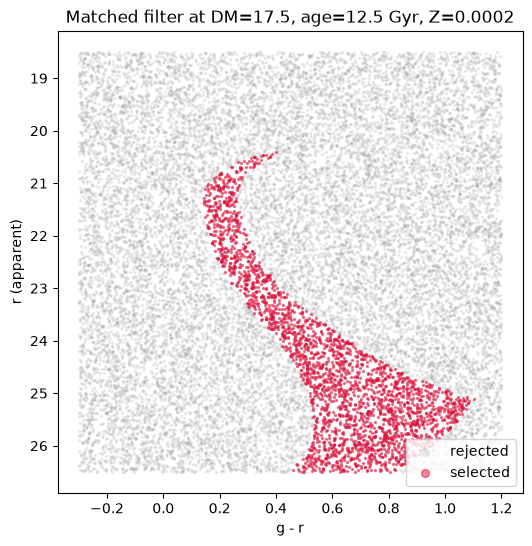

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(cand_color[~cand_selected], cand_r[~cand_selected], s=2, alpha=0.15, color="0.6", label="rejected")
ax.scatter(cand_color[cand_selected], cand_r[cand_selected], s=2, alpha=0.5, color="crimson", label="selected")
ax.invert_yaxis()
ax.set_xlabel("g - r")
ax.set_ylabel("r (apparent)")
ax.set_title(f"Matched filter at DM={distance_modulus}, age={iso_config['age']} Gyr, Z={iso_config['z']}")
ax.legend(markerscale=4)
plt.show()

## 2. `pixel_scale_deg` is auto-derived from `nside` (and can't be set too fine)

`project()` bilinearly interpolates 4 HEALPix neighbor pixels onto whatever
output grid `PixelizationSpec.pixel_scale_deg` asks for. If that's much finer
than the map's own native pixel size, the output image *looks* smoother and
higher-resolution than it actually is — the extra "detail" is manufactured by
the interpolation, not sampled from real data. So `pixel_scale_deg` is
**optional**: omit it and `PixelizationSpec` auto-derives it from `nside` via
`native_pixel_scale_deg(nside)`. If you pass a value explicitly that's more
than 2x finer than that native resolution, construction raises `ValueError`
outright — you can still deliberately choose a *coarser*-than-native value,
just not a finer one.

In [4]:
for nside in [64, 128, 256, 512]:
    print(f"nside={nside:4d} -> native pixel scale = {native_pixel_scale_deg(nside):.4f} deg")

nside=  64 -> native pixel scale = 0.9161 deg
nside= 128 -> native pixel scale = 0.4581 deg
nside= 256 -> native pixel scale = 0.2290 deg
nside= 512 -> native pixel scale = 0.1145 deg


In [5]:
# Omitted -> auto-derived from nside.
auto_pix = PixelizationSpec(nside=256)
print("auto-derived pixel_scale_deg @ nside=256:", auto_pix.pixel_scale_deg)

# Explicit and far too fine for nside=256's ~0.23 deg/pixel native resolution -> raises.
try:
    PixelizationSpec(nside=256, pixel_scale_deg=0.01)
except ValueError as exc:
    print("\noversampled (0.01 deg @ nside=256) raises:\n ", exc)

auto-derived pixel_scale_deg @ nside=256: 0.22903242745449373

oversampled (0.01 deg @ nside=256) raises:
  pixel_scale_deg=0.01 deg is more than 2x finer than nside=256's native HEALPix resolution (0.229 deg/pixel). The projected image would imply more angular detail than the map was ever sampled at. Omit pixel_scale_deg to auto-derive it from nside, or pass a coarser value, or increase nside.


## 3. A synthetic sky: background field stars + one stream

`select()` needs real `(ra, dec)` positions to build a HEALPix map, so we
place two synthetic catalogs on the sky:

- a **background** of field stars scattered uniformly over a patch of sky
  (dense enough to fully cover our demo window at the `nside` chosen below —
  see §2), with the *same* broad, mostly off-isochrone color-magnitude
  distribution as above (so most of it gets rejected by the filter);
- a thin **stream** track (400 stars along a straight line with a little
  perpendicular scatter), with magnitudes resampled from the subset of
  candidates *already known to pass the filter* — so, unlike the background,
  most stream stars should be selected.

In [6]:
center_ra, center_dec = 180.0, 0.0

# --- Background: scattered over a patch comfortably larger than the demo window
# (24 deg, see §4) so make_raw_map's valid_mask isn't clipped by the patch edge.
# Density is tuned (empirically, via the "valid fraction" print further down) so
# the window is well covered at nside=256 -- a real background catalog is far
# denser than this at native HEALPix resolution; we just need "enough."
n_bg = 80_000
patch_half_width_deg = 14.0
bg_ra = rng.uniform(center_ra - patch_half_width_deg, center_ra + patch_half_width_deg, n_bg)
bg_dec = rng.uniform(center_dec - patch_half_width_deg, center_dec + patch_half_width_deg, n_bg)
bg_r = rng.uniform(distance_modulus + 1, distance_modulus + 9, n_bg)
bg_color = rng.uniform(-0.3, 1.2, n_bg)
bg_g = bg_r + bg_color

background = pd.DataFrame({
    "ra": bg_ra, "dec": bg_dec,
    f"{namespace}_g_obs": bg_g, f"{namespace}_r_obs": bg_r,
})

# --- Stream: a straight track, magnitudes drawn from the isochrone-consistent subset.
n_stream = 400
t = rng.uniform(0, 1, n_stream)
stream_ra = (center_ra - 8) + 16 * t + rng.normal(0, 0.08, n_stream)
stream_dec = (center_dec - 4) + 8 * t + rng.normal(0, 0.08, n_stream)

in_filter_idx = rng.choice(np.flatnonzero(cand_selected), size=n_stream, replace=True)
stream = pd.DataFrame({
    "ra": stream_ra, "dec": stream_dec,
    f"{namespace}_g_obs": cand_g[in_filter_idx], f"{namespace}_r_obs": cand_r[in_filter_idx],
})

bg_selected = filt.select(background, ["g", "r"], distance_modulus)
stream_selected = filt.select(stream, ["g", "r"], distance_modulus)
print(f"Background: {bg_selected.sum()} / {len(background)} selected (contamination)")
print(f"Stream:     {stream_selected.sum()} / {len(stream)} selected")

Background: 10694 / 80000 selected (contamination)
Stream:     400 / 400 selected


## 4. `make_raw_map`: pixelizing selected stars onto HEALPix

Each catalog is pixelized separately. `valid_mask` marks pixels the catalog
actually covers (any row, selected or not) — for the background this traces
real sky coverage; for the stream (a handful of stars in a few pixels) it
isn't meant to be used downstream (see the function's docstring), only the
background's own `valid_mask` is authoritative.

`pixel_scale_deg=0.24` is chosen to match `nside=256`'s native resolution
(§2) — no artificial oversampling.

In [7]:
pix = PixelizationSpec(
    nside=256,
    center_ra=center_ra,
    center_dec=center_dec,
    image_size_pix=(100, 100),
    pixel_scale_deg=0.24,
    interpolate=True,
)
print(f"window size: {100 * 0.24:.1f} deg (native resolution at this nside: {native_pixel_scale_deg(256):.3f} deg)")

bg_raw_full, bg_valid_full = make_raw_map(background, bg_selected, pix)
stream_raw_full, _stream_valid_full = make_raw_map(stream, stream_selected, pix)

print("npix:", bg_raw_full.shape[0])
print("background: total selected-star count on the map =", bg_raw_full.sum())
print("background: valid (covered) pixels =", bg_valid_full.sum())
print("stream: total selected-star count on the map =", stream_raw_full.sum())

window size: 24.0 deg (native resolution at this nside: 0.229 deg)
npix: 786432
background: total selected-star count on the map = 10694.0
background: valid (covered) pixels = 14908
stream: total selected-star count on the map = 400.0


## 5. `combine_full_maps` + `project`: background, stream, and combined

`combine_full_maps` sums the two full-sky HEALPix maps (additive, since
`select()` is an unweighted hard cut). `project` then turns each full-sky
map into a 2D image centered on our window via gnomonic projection with
bilinear HEALPix interpolation — this is the map a U-Net would actually see.

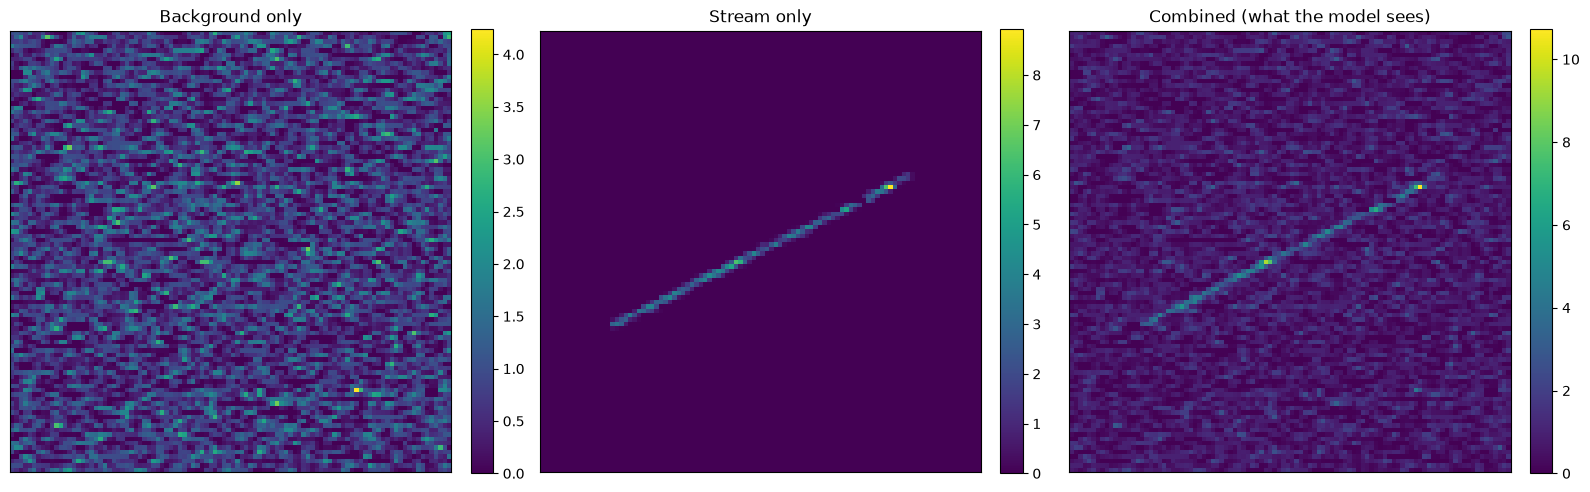

combined image valid fraction: 0.986


In [8]:
combined_raw_full = combine_full_maps(bg_raw_full, stream_raw_full, bg_valid_full)

bg_image, _ = project(bg_raw_full, bg_valid_full, pix)
stream_image, _ = project(stream_raw_full, bg_valid_full, pix)
combined_image, combined_valid = project(combined_raw_full, bg_valid_full, pix)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, img, title in zip(
    axes, [bg_image, stream_image, combined_image],
    ["Background only", "Stream only", "Combined (what the model sees)"],
):
    im = ax.imshow(img, origin="lower", cmap="viridis")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("combined image valid fraction:", combined_valid.mean())

## 6. Interpolation: bilinear vs. nearest-pixel

`PixelizationSpec.interpolate` controls whether `project` bilinearly
interpolates the 4 nearest HEALPix neighbors (`hp.get_interp_weights`) or
just looks up the nearest pixel. Both specs below use `nside=64` — coarse
enough that individual HEALPix pixels are big and easy to see — with
`pixel_scale_deg` omitted (auto-derived, so still non-oversampled per §2).

pixel_scale_deg (auto-derived @ nside=64): 0.9161297098179749


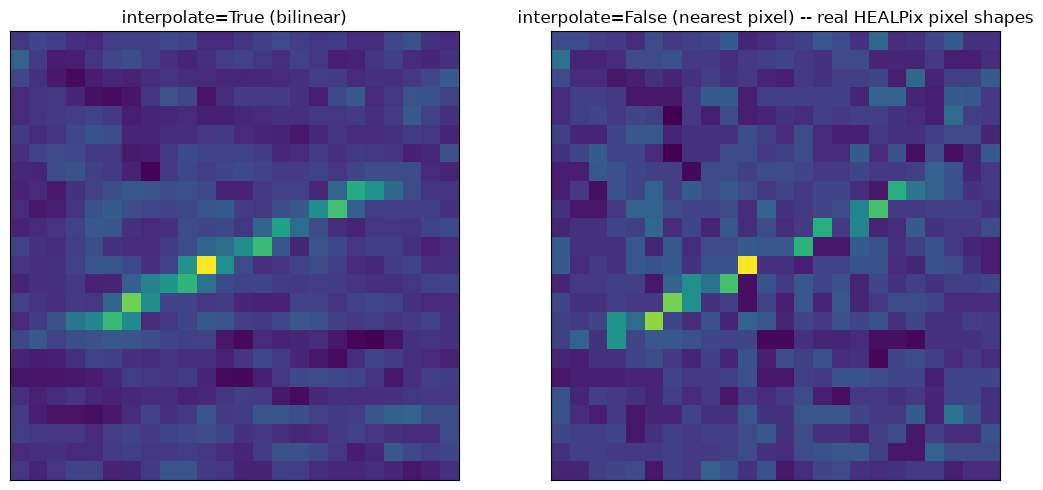

In [9]:
pix_coarse_interp = PixelizationSpec(
    nside=64, center_ra=center_ra, center_dec=center_dec,
    image_size_pix=(24, 24), interpolate=True,
)
pix_coarse_nearest = dataclasses.replace(pix_coarse_interp, interpolate=False)
print("pixel_scale_deg (auto-derived @ nside=64):", pix_coarse_interp.pixel_scale_deg)

raw_coarse, valid_coarse = make_raw_map(background, bg_selected, pix_coarse_interp)
raw_coarse_combined = combine_full_maps(
    raw_coarse, make_raw_map(stream, stream_selected, pix_coarse_interp)[0], valid_coarse
)

img_interp, _ = project(raw_coarse_combined, valid_coarse, pix_coarse_interp)
img_nearest, _ = project(raw_coarse_combined, valid_coarse, pix_coarse_nearest)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(img_interp, origin="lower", cmap="viridis")
axes[0].set_title("interpolate=True (bilinear)")
axes[1].imshow(img_nearest, origin="lower", cmap="viridis")
axes[1].set_title("interpolate=False (nearest pixel) -- real HEALPix pixel shapes")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 7. No RA-stretching near the pole

Gnomonic (tangent-plane) projection with the module's own rotation handling
must not show the naive `ra × dec` histogram artifact where equal-angle
offsets appear stretched in RA at high declination. We project the *same*
uniform full-sky map centered at `dec=0°` and `dec=80°` — both should look
equally flat. `pixel_scale_deg` is omitted (auto-derived from `nside=128`).

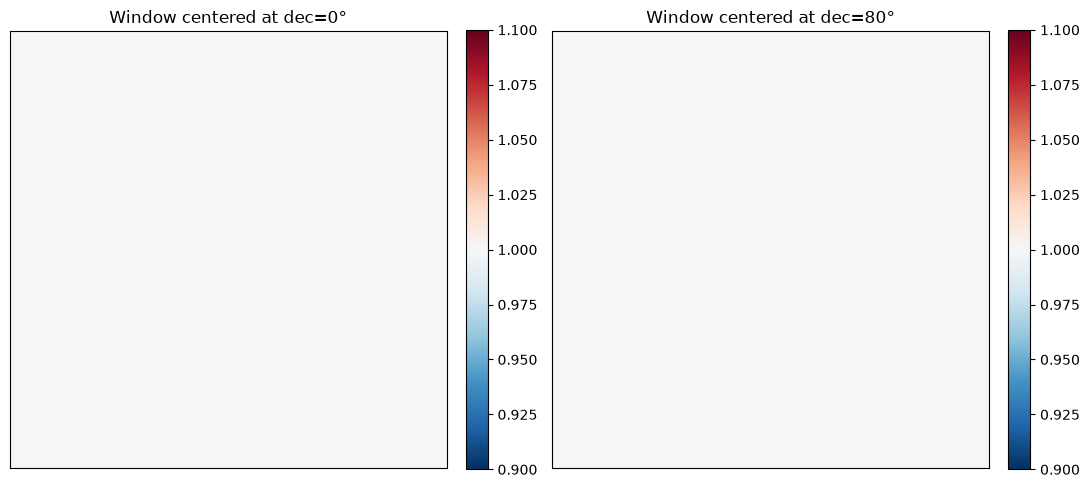

dec=0°:  min=1.000000  max=1.000000  std=4.53e-17
dec=80°: min=1.000000  max=1.000000  std=4.61e-17
Both are flat to within floating-point interpolation noise, despite the very different declination.


In [10]:
npix = hp.nside2npix(128)
uniform_map = np.ones(npix)
uniform_valid = np.ones(npix, dtype=bool)

pix_low_dec = PixelizationSpec(nside=128, center_ra=180.0, center_dec=0.0, image_size_pix=(60, 60))
pix_high_dec = PixelizationSpec(nside=128, center_ra=180.0, center_dec=80.0, image_size_pix=(60, 60))

img_low, _ = project(uniform_map, uniform_valid, pix_low_dec)
img_high, _ = project(uniform_map, uniform_valid, pix_high_dec)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
im0 = axes[0].imshow(img_low, origin="lower", vmin=0.9, vmax=1.1, cmap="RdBu_r")
axes[0].set_title("Window centered at dec=0°")
im1 = axes[1].imshow(img_high, origin="lower", vmin=0.9, vmax=1.1, cmap="RdBu_r")
axes[1].set_title("Window centered at dec=80°")
for ax, im in zip(axes, [im0, im1]):
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(f"dec=0°:  min={img_low.min():.6f}  max={img_low.max():.6f}  std={img_low.std():.2e}")
print(f"dec=80°: min={img_high.min():.6f}  max={img_high.max():.6f}  std={img_high.std():.2e}")
print("Both are flat to within floating-point interpolation noise, despite the very different declination.")

## 8. Window rotation

`rotation_deg` is applied as part of the tangent-plane projection itself
(not a post-hoc image rotation). Projecting the same combined stream map at
two different rotations should show the stream track at two different
position angles in the image.

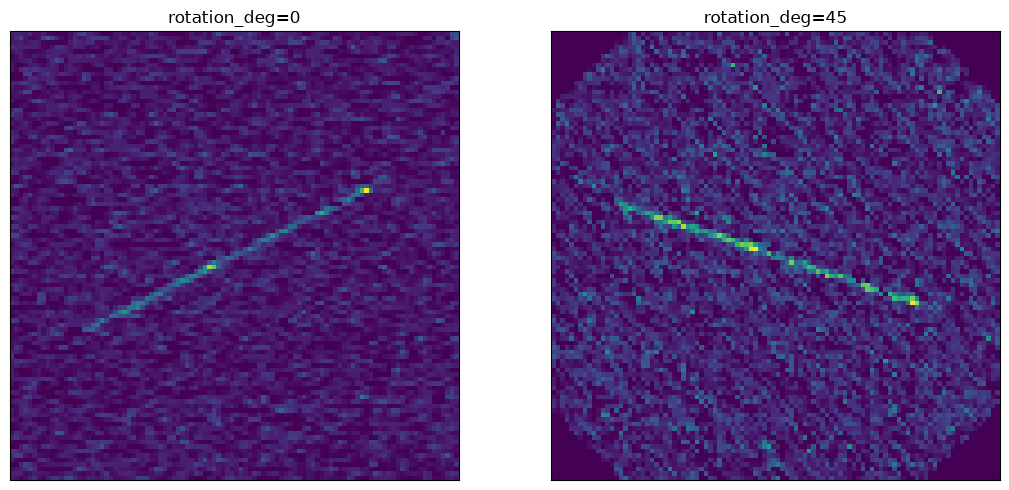

In [11]:
pix_rot0 = PixelizationSpec(nside=256, center_ra=center_ra, center_dec=center_dec,
                             rotation_deg=0.0, image_size_pix=(100, 100), pixel_scale_deg=0.24)
pix_rot45 = PixelizationSpec(nside=256, center_ra=center_ra, center_dec=center_dec,
                              rotation_deg=45.0, image_size_pix=(100, 100), pixel_scale_deg=0.24)

img_rot0, _ = project(combined_raw_full, bg_valid_full, pix_rot0)
img_rot45, _ = project(combined_raw_full, bg_valid_full, pix_rot45)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(img_rot0, origin="lower", cmap="viridis")
axes[0].set_title("rotation_deg=0")
axes[1].imshow(img_rot45, origin="lower", cmap="viridis")
axes[1].set_title("rotation_deg=45")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 9. `crop_window`: cropping a finalized full-sky map to one window

`crop_window` takes an already-finalized full-sky map (here, standing in for
what `finalize_full` would produce once background smoothing is wired up)
and crops it to one `Window`'s center/rotation — it's a thin wrapper around
`project` with the window's own center/rotation substituted in. `windows.py`
isn't implemented yet, so we duck-type a minimal window here.

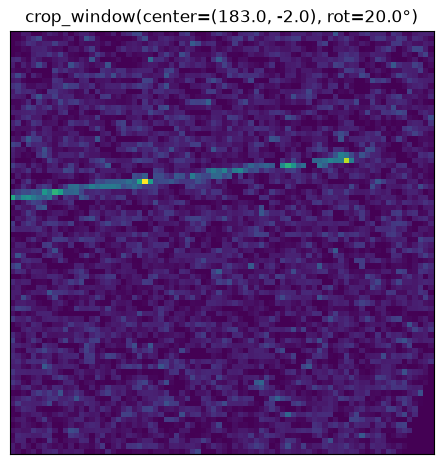

windowed valid fraction: 0.97484375


In [12]:
from dataclasses import dataclass


@dataclass
class DemoWindow:
    center_ra: float
    center_dec: float
    rotation_deg: float


window = DemoWindow(center_ra=center_ra + 3.0, center_dec=center_dec - 2.0, rotation_deg=20.0)
base_pix = PixelizationSpec(nside=256, image_size_pix=(80, 80), pixel_scale_deg=0.24)

windowed_image, windowed_valid = crop_window(combined_raw_full, bg_valid_full, window, base_pix)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(windowed_image, origin="lower", cmap="viridis")
ax.set_title(f"crop_window(center=({window.center_ra}, {window.center_dec}), rot={window.rotation_deg}°)")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

print("windowed valid fraction:", windowed_valid.mean())

## Summary

- `StreamobsSplineFilter.select()` — hard color-magnitude cut around a
  reference isochrone, via the real `streamobs`/`ugali` isochrone machinery.
- `native_pixel_scale_deg(nside)` — `pixel_scale_deg` is optional and
  auto-derives from `nside` when omitted; passing an explicit value finer
  than the native resolution raises `ValueError` rather than silently
  fabricating detail through interpolation (§2).
- `make_raw_map` — pixelizes selected stars to HEALPix counts, with an
  explicit `valid_mask` distinguishing "zero stars here" from "no coverage
  here."
- `combine_full_maps` — additive combination of background + stream raw maps.
- `project` — gnomonic HEALPix → image projection, with rotation and optional
  bilinear interpolation, verified flat at high declination (no RA-stretching).
- `crop_window` — crops an already-finalized full-sky map to one window.

See `claude/PLAN.md` for what's implemented so far and what's still open.